In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt

In [2]:
def load_data():
    X = np.load("data/X.npy")
    y = np.load("data/y.npy")
    X = X[0:1000]
    y = y[0:1000]
    return X, y

In [3]:
# load dataset
X, y = load_data()

In [4]:
print ('The first element of X is: ', X[0])

The first element of X is:  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+

In [5]:
print ('The first element of y is: ', y[0,0])
print ('The last element of y is: ', y[-1,0])

The first element of y is:  0
The last element of y is:  1


In [6]:
print ('The first element of y is: ', y[0]) # we get an array 1x1
print ('The last element of y is: ', y[-1]) # we get an array 1x1

The first element of y is:  [0]
The last element of y is:  [1]


In [7]:
print ('The shape of X is: ' , X.shape)
print ('The shape of y is: ' , y.shape)

The shape of X is:  (1000, 400)
The shape of y is:  (1000, 1)


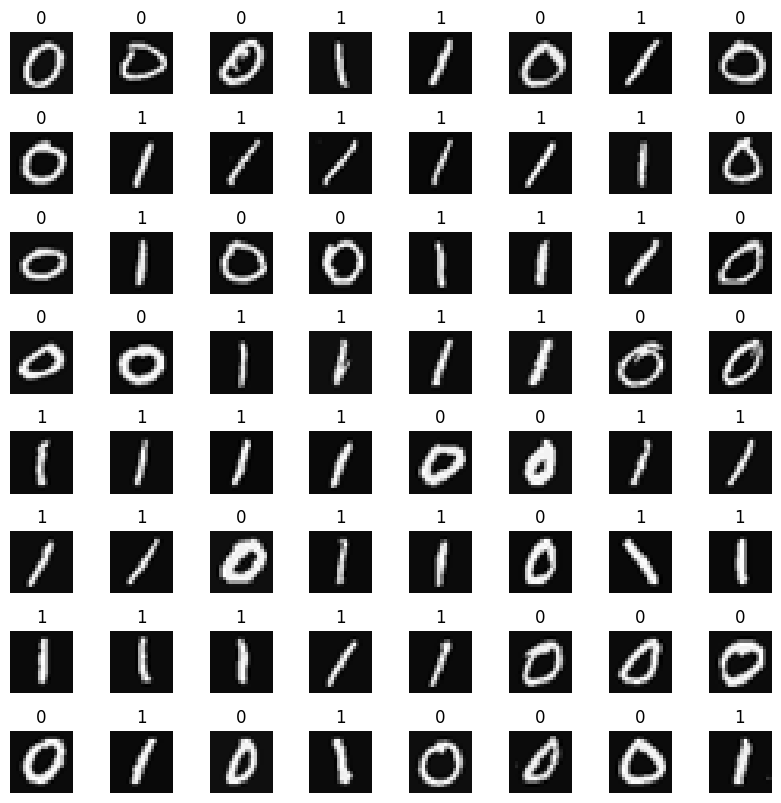

In [8]:
m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1)

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)

    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T

    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    # Display the label above the image
    ax.set_title(y[random_index,0])
    ax.set_axis_off()

# EXO 1:

In [9]:
model = Sequential(
    [
        tf.keras.Input(shape=(400,)),    #specify input size
        ### START CODE HERE ###

        Dense(25, activation='sigmoid', name='layer1'),  # hidden layer 1
        Dense(15, activation='sigmoid', name='layer2'),  # hidden layer 2
        Dense(1, activation='sigmoid', name='layer3'),   # output layer
        ### END CODE HERE ###
    ], 
    name="my_model"
)

# TEST EXO1:

In [10]:
model.summary()

Model: "my_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 25)             │        10,025 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,431 (40.75 KB)

 Trainable params: 10,431 (40.75 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
L1_num_params = 400 * 25 + 25  # W1 parameters  + b1 parameters
L2_num_params = 25 * 15 + 15   # W2 parameters  + b2 parameters
L3_num_params = 15 * 1 + 1     # W3 parameters  + b3 parameters
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params, ",  L3 params = ", L3_num_params )

L1 params =  10025 , L2 params =  390 ,  L3 params =  16


In [12]:
[layer1, layer2, layer3] = model.layers
#### Examine Weights shapes
W1,b1 = layer1.get_weights()
W2,b2 = layer2.get_weights()
W3,b3 = layer3.get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 1), b3 shape = (1,)


In [13]:
print(model.layers[2].weights)

[<Variable path=my_model/layer3/kernel, shape=(15, 1), dtype=float32, value=[[-0.16870776]
 [ 0.25671715]
 [ 0.07916832]
 [ 0.58081776]
 [-0.0502001 ]
 [ 0.2990839 ]
 [-0.3246196 ]
 [ 0.5971053 ]
 [ 0.20605642]
 [ 0.3631606 ]
 [ 0.03028703]
 [-0.3528509 ]
 [-0.5077362 ]
 [-0.00391358]
 [ 0.60256356]]>, <Variable path=my_model/layer3/bias, shape=(1,), dtype=float32, value=[0.]>]


In [14]:
model.save("my_model.keras")

# EXO2 :

In [15]:
# YOUR CODE GOES HERE

# configure the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X, y,
    epochs=20,
    batch_size=32,   # you can adjust batch size
    validation_split=0.2,  # optional, split 20% for validation
    verbose=1
)

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5888 - loss: 0.6741 - val_accuracy: 0.9950 - val_loss: 0.5736
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9925 - loss: 0.5273 - val_accuracy: 0.9850 - val_loss: 0.5517
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9925 - loss: 0.4289 - val_accuracy: 0.9900 - val_loss: 0.4253
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9950 - loss: 0.3364 - val_accuracy: 0.9900 - val_loss: 0.3161
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9950 - loss: 0.2620 - val_accuracy: 0.9950 - val_loss: 0.2420
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9962 - loss: 0.2065 - val_accuracy: 0.9950 - val_loss: 0.1911
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9962 - loss: 0.1660 - val_accuracy: 0.9950 - val_loss: 0.1543
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9962 - loss: 0.1365 - val_accuracy: 0.9950 - val_los

# TEST EXO2 :

In [16]:
prediction = model.predict(X[0].reshape(1,400))  # a zero
print(f" predicting a zero: {prediction}")
prediction = model.predict(X[500].reshape(1,400))  # a one
print(f" predicting a one:  {prediction}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
 predicting a zero: [[0.03072689]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
 predicting a one:  [[0.9745814]]


In [17]:
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print(f"prediction after threshold: {yhat}")

prediction after threshold: 1


In [18]:
Yhat = (model.predict(X)>=0.5).astype(int)
# Number of correctly classified samples
print('Number of correctly classified sample', np.sum(Yhat==y))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
Number of correctly classified sameple 998


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━

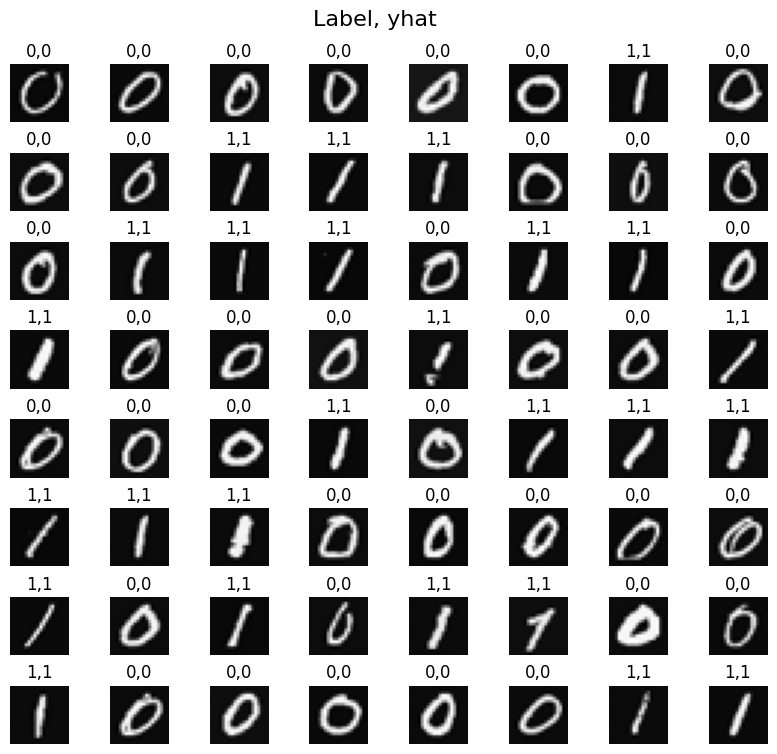

In [19]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1,rect=[0, 0.03, 1, 0.92]) #[left, bottom, right, top]

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)

    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T

    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    # Predict using the Neural Network
    prediction = model.predict(X[random_index].reshape(1,400))
    if prediction >= 0.5:
        yhat = 1
    else:
        yhat = 0

    # Display the label above the image
    ax.set_title(f"{y[random_index,0]},{yhat}")
    ax.set_axis_off()
fig.suptitle("Label, yhat", fontsize=16)
plt.show()

# EXO3 :

In [21]:
import torch
import torch.nn as nn   # <-- this defines `nn`

class DigitRecognitionNet(nn.Module):
    def __init__(self):
        super(DigitRecognitionNet, self).__init__()

        # Define layers
        self.layer1 = nn.Linear(400, 25)
        self.layer2 = nn.Linear(25, 15)
        self.layer3 = nn.Linear(15, 1)
        self.sigmoid = nn.Sigmoid()  # activation function

    def forward(self, x):
        x = self.sigmoid(self.layer1(x))  # Layer 1
        x = self.sigmoid(self.layer2(x))  # Layer 2
        x = self.sigmoid(self.layer3(x))  # Layer 3 (output)
        return x

# TEST EXO3:

In [22]:
from torchsummary import summary
model = DigitRecognitionNet ()
summary(model, input_size=(1, 400))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 25]          10,025
           Sigmoid-2                [-1, 1, 25]               0
            Linear-3                [-1, 1, 15]             390
           Sigmoid-4                [-1, 1, 15]               0
            Linear-5                 [-1, 1, 1]              16
           Sigmoid-6                 [-1, 1, 1]               0
Total params: 10,431
Trainable params: 10,431
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04
----------------------------------------------------------------


In [23]:
L1_num_params = 400 * 25 + 25  # W1 parameters  + b1 parameters
L2_num_params = 25 * 15 + 15   # W2 parameters  + b2 parameters
L3_num_params = 15 * 1 + 1     # W3 parameters  + b3 parameters
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params, ",  L3 params = ", L3_num_params )

L1 params =  10025 , L2 params =  390 ,  L3 params =  16


In [24]:
# Access weights and biases for each layer
W1, b1 = model.layer1.weight, model.layer1.bias
W2, b2 = model.layer2.weight, model.layer2.bias
W3, b3 = model.layer3.weight, model.layer3.bias

# Print shapes of weights and biases
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = torch.Size([25, 400]), b1 shape = torch.Size([25])
W2 shape = torch.Size([15, 25]), b2 shape = torch.Size([15])
W3 shape = torch.Size([1, 15]), b3 shape = torch.Size([1])


In [25]:
print(model.layer3.weight.data)

tensor([[-0.1738, -0.1423, -0.1619,  0.0855, -0.0158,  0.1434, -0.0525, -0.0197,
          0.1495,  0.2357, -0.2017, -0.2461,  0.1571,  0.1676, -0.0403]])


# EXO4 :

In [28]:
import torch.optim as optim


criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

for epoch in range(20):
    optimizer.zero_grad()
    y_pred = model(X_tensor)
    loss = criterion(y_pred, y_tensor)
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 0.6163
Epoch 2, Loss: 0.6131
Epoch 3, Loss: 0.6099
Epoch 4, Loss: 0.6066
Epoch 5, Loss: 0.6033
Epoch 6, Loss: 0.6000
Epoch 7, Loss: 0.5966
Epoch 8, Loss: 0.5932
Epoch 9, Loss: 0.5897
Epoch 10, Loss: 0.5862
Epoch 11, Loss: 0.5826
Epoch 12, Loss: 0.5790
Epoch 13, Loss: 0.5754
Epoch 14, Loss: 0.5717
Epoch 15, Loss: 0.5680
Epoch 16, Loss: 0.5642
Epoch 17, Loss: 0.5604
Epoch 18, Loss: 0.5566
Epoch 19, Loss: 0.5528
Epoch 20, Loss: 0.5489


# TEST EXO4 :

In [29]:
prediction = model(X_tensor[0].reshape(1,400))  # a zero
print(f" predicting a zero: {prediction}")
prediction = model(X_tensor[500].reshape(1,400))  # a one
print(f" predicting a one:  {prediction}")

 predicting a zero: tensor([[0.4207]], grad_fn=<SigmoidBackward0>)
 predicting a one:  tensor([[0.5858]], grad_fn=<SigmoidBackward0>)


In [30]:
if prediction >= 0.5:
    yhat = 1
else:
    yhat = 0
print(f"prediction after threshold: {yhat}")

prediction after threshold: 1


In [31]:
Yhat = (model(X_tensor)>=0.5).numpy().astype(int)
# Number of correctly classified samples
print('Number of correctly classified sameple', np.sum(Yhat==y))

Number of correctly classified sameple 992


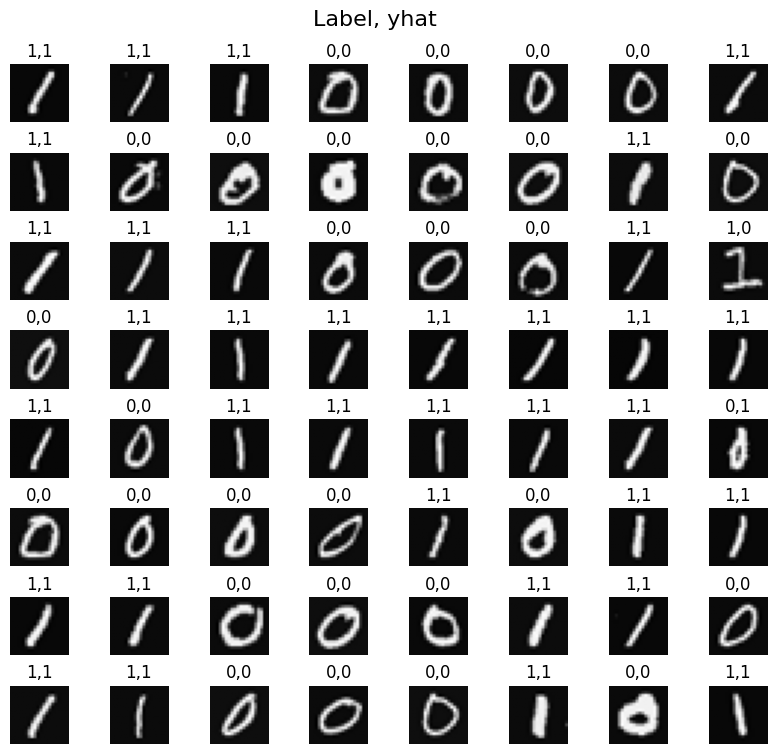

In [32]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(8,8))
fig.tight_layout(pad=0.1,rect=[0, 0.03, 1, 0.92]) #[left, bottom, right, top]

for i,ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)

    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20,20)).T

    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    # Predict using the Neural Network
    prediction = model(X_tensor[random_index].reshape(1,400))
    if prediction >= 0.5:
        yhat = 1
    else:
        yhat = 0

    # Display the label above the image
    ax.set_title(f"{y[random_index,0]},{yhat}")
    ax.set_axis_off()
fig.suptitle("Label, yhat", fontsize=16)
plt.show()

# EXO5 :

In [33]:
def my_dense(A_in, W, b, g):
    
    Z = np.dot(A_in, W) + b
    A_out = g(Z)
    
    return A_out

In [35]:
def sigmoid(z):

    g = 1/(1+np.exp(-z))
    
    return g

In [36]:
def relu(z):

    g = np.maximum(0, z)
    
    return g

In [38]:
X_tst = 0.1*np.arange(1,9,1).reshape(4,2) # (4 examples, 2 features)
W_tst = 0.1*np.arange(1,7,1).reshape(2,3) # (2 input features, 3 output features)
b_tst = 0.1*np.arange(1,4,1).reshape(1,3) # (1, 3 features)
A_tst = my_dense(X_tst, W_tst, b_tst, sigmoid)
print(A_tst)

[[0.54735762 0.57932425 0.61063923]
 [0.57199613 0.61301418 0.65248946]
 [0.5962827  0.64565631 0.6921095 ]
 [0.62010643 0.67699586 0.72908792]]


In [39]:
def my_sequential(X, W1, b1, W2, b2, W3, b3):

    A1 = my_dense(X,  W1, b1, sigmoid)
    A2 = my_dense(A1, W2, b2, sigmoid)
    A3 = my_dense(A2, W3, b3, sigmoid)

    return A3

# TEST EXO5 :

In [40]:
W1_tmp,b1_tmp = layer1.get_weights()
W2_tmp,b2_tmp = layer2.get_weights()
W3_tmp,b3_tmp = layer3.get_weights()

In [41]:
Prediction = my_sequential(X, W1_tmp, b1_tmp, W2_tmp, b2_tmp, W3_tmp, b3_tmp )
Prediction.shape

(1000, 1)

In [43]:
Yhat = (Prediction >= 0.5).astype(int)
print("predict a zero: ",Yhat[0], "predict a one: ", Yhat[500])

predict a zero:  [0] predict a one:  [1]


In [44]:
# Number of correctly classified samples
print('Number of correctly classified sameple', np.sum(Yhat==y))

Number of correctly classified sameple 998


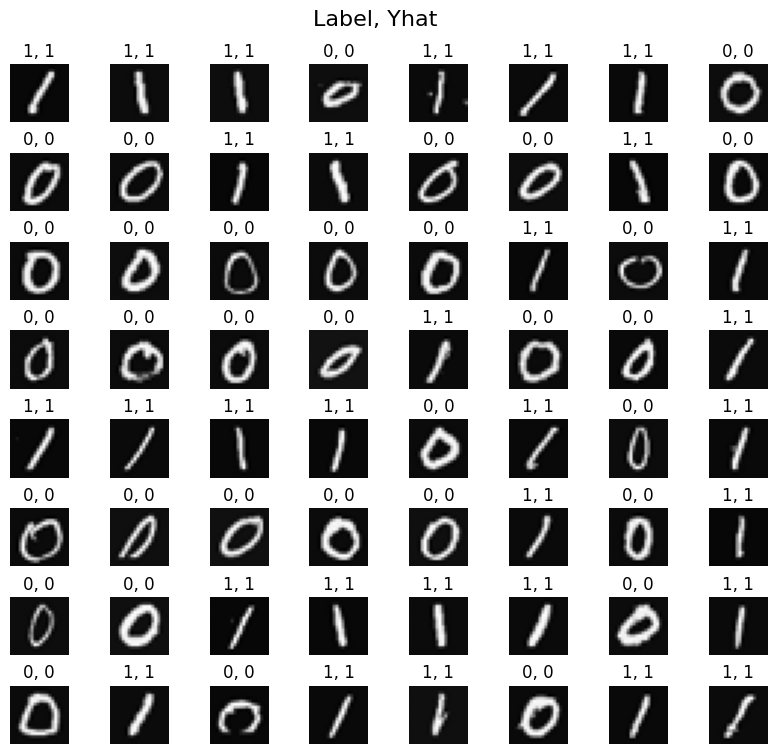

In [45]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# You do not need to modify anything in this cell

m, n = X.shape

fig, axes = plt.subplots(8, 8, figsize=(8, 8))
fig.tight_layout(pad=0.1, rect=[0, 0.03, 1, 0.92]) #[left, bottom, right, top]

for i, ax in enumerate(axes.flat):
    # Select random indices
    random_index = np.random.randint(m)

    # Select rows corresponding to the random indices and
    # reshape the image
    X_random_reshaped = X[random_index].reshape((20, 20)).T

    # Display the image
    ax.imshow(X_random_reshaped, cmap='gray')

    # Display the label above the image
    ax.set_title(f"{y[random_index,0]}, {Yhat[random_index, 0]}")
    ax.set_axis_off()
fig.suptitle("Label, Yhat", fontsize=16)
plt.show()